# Lab 5: LSTM Text Classification
## Objective:
Build an LSTM model to classify IMDB movie reviews into positive or negative sentiment.

In [2]:
# Step 1: Import Libraries
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import imdb
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [3]:
# Step 2: Load Dataset
vocab_size = 10000
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)

In [4]:
# Step 3: Preprocessing
max_len = 200
X_train = pad_sequences(X_train, maxlen=max_len)
X_test = pad_sequences(X_test, maxlen=max_len)

In [5]:
# Step 4: Build Model
model = Sequential()
model.add(Embedding(input_dim=vocab_size, output_dim=128, input_length=max_len))
model.add(LSTM(64, dropout=0.2, recurrent_dropout=0.2))
model.add(Dense(1, activation='sigmoid'))
model.summary()

C:\Users\nikhi\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [6]:
# Step 5: Compile Model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [7]:
# Step 6: Train Model
history = model.fit(X_train, y_train, epochs=5, batch_size=64, validation_split=0.2)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 108s 305ms/step - accuracy: 0.7478 - loss: 0.5042 - val_accuracy: 0.8394 - val_loss: 0.3861
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 97s 310ms/step - accuracy: 0.8557 - loss: 0.3429 - val_accuracy: 0.8470 - val_loss: 0.3645
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 136s 291ms/step - accuracy: 0.8934 - loss: 0.2729 - val_accuracy: 0.8350 - val_loss: 0.3802
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 64s 206ms/step - accuracy: 0.9098 - loss: 0.2342 - val_accuracy: 0.8560 - val_loss: 0.3959
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 69s 221ms/step - accuracy: 0.9255 - loss: 0.1984 - val_accuracy: 0.8466 - val_loss: 0.4304


In [8]:
# Step 7: Evaluate Model
loss, accuracy = model.evaluate(X_test, y_test)
print('Test Accuracy:', accuracy)

782/782 ━━━━━━━━━━━━━━━━━━━━ 20s 26ms/step - accuracy: 0.8489 - loss: 0.4299
Test Accuracy: 0.8488799929618835


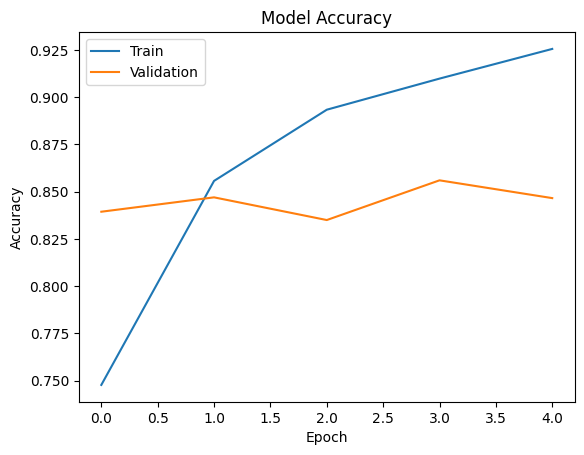

In [9]:
# Step 8: Plot Accuracy Graph
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()